# Crash Severity Analysis, 2022–2024

**Research question:**
Which behavioral and environmental characteristics are most strongly associated with severe or fatal outcomes in U.S. police-reported crashes from 2022 to 2024?

**Data:** NHTSA Crash Report Sampling System (CRSS), 2022–2024 — `accident` (crash-level) and `vehicle` (vehicle-level) files.

## 1. Setup and load the CRSS files

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.lines import Line2D
%pip install statsmodels
import statsmodels.api as sm
import statsmodels.formula.api as smf
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)   # pandas deprecation notices only
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

# Notebook can live in the project root or in notebook/
ROOT = Path.cwd().parent if Path.cwd().name == "Notebook" else Path.cwd()
RAW = ROOT / "Data" / "raw"
PROC = ROOT / "Data" / "processed"
FIG = ROOT / "Figures"

PROC.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)

Note: you may need to restart the kernel to use updated packages.


In [2]:
ACCENT = "#d9581f"   # severe/fatal, or the characteristic of interest
BASE = "#a7b0ba"     # comparison group
BLUE = "#2a78d6"     # second color (e.g., crash volume, protective factors)
INK = "#1f2a3d"      # text
MUTED = "#6b7785"    # secondary text, reference lines

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "font.size": 11, "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.titlepad": 12, "axes.labelcolor": INK, "axes.edgecolor": "#c9cfd6", "text.color": INK,
    "xtick.color": MUTED, "ytick.color": INK, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "legend.frameon": False,
})


def save(name):
    plt.savefig(FIG / f"{name}.png")
    plt.show()

We only load the columns needed for this research question.
Using the CRSS `...NAME` columns makes the code easier to read and avoids manually decoding most numeric codes.

In [3]:
ACC_COLS = [
    "CASENUM", "YEAR", "PSU_VAR", "PSUSTRAT", "WEIGHT",
    "MAXSEV_IMNAME", "ALCHL_IMNAME",
    "HOUR_IM", "WKDY_IMNAME",
    "LGTCON_IMNAME", "WEATHR_IMNAME",
    "URBANICITYNAME", "RELJCT2_IMNAME", "INT_HWYNAME"
]

VEH_COLS = ["CASENUM", "SPEEDRELNAME"]

acc_list = []
veh_list = []

for acc_file in sorted(RAW.glob("accident*.csv")):
    veh_file = RAW / acc_file.name.replace("accident", "vehicle")

    if not veh_file.exists():
        raise FileNotFoundError(f"Could not find matching file for {acc_file.name}: {veh_file.name}")

    acc = pd.read_csv(acc_file, usecols=ACC_COLS, encoding="latin1", low_memory=False)
    veh = pd.read_csv(veh_file, usecols=VEH_COLS, encoding="latin1", low_memory=False)

    year = int(acc["YEAR"].iloc[0])
    veh["YEAR"] = year

    print(f"{year}: {len(acc):,} crashes, {len(veh):,} vehicle records")

    acc_list.append(acc)
    veh_list.append(veh)

acc_raw = pd.concat(acc_list, ignore_index=True)
veh_raw = pd.concat(veh_list, ignore_index=True)

print(f"\nPooled: {len(acc_raw):,} crashes and {len(veh_raw):,} vehicle records")

2022: 53,955 crashes, 94,756 vehicle records
2023: 50,103 crashes, 87,461 vehicle records
2024: 51,658 crashes, 90,641 vehicle records

Pooled: 155,716 crashes and 272,858 vehicle records


In [4]:
# Basic integrity checks
assert not acc_raw.duplicated(["YEAR", "CASENUM"]).any(), "Duplicate crash IDs found."

print("\nCrashes by year:")
display(acc_raw["YEAR"].value_counts().sort_index().rename("crashes").to_frame())

print("Years in the dataset:", sorted(acc_raw["YEAR"].unique()))


Crashes by year:


,crashes
YEAR,
2022,53955
2023,50103
2024,51658


Years in the dataset: [np.int64(2022), np.int64(2023), np.int64(2024)]


## 2. Clean the crash-level variables

### 2.1 Define the outcome

The outcome is binary:

- **1 = severe/fatal:** suspected serious injury (A) or fatal injury (K)
- **0 = less severe:** no apparent injury (O), possible injury (C), or suspected minor injury (B)

Crashes with unknown/non-applicable maximum severity are excluded.

In [5]:
valid_severity = [
    "No Apparent Injury (O)",
    "Possible Injury (C)",
    "Suspected Minor Injury (B)",
    "Suspected Serious Injury (A)",
    "Fatal Injury (K)"
]

acc = acc_raw[acc_raw["MAXSEV_IMNAME"].isin(valid_severity)].copy()

acc["severe_fatal"] = acc["MAXSEV_IMNAME"].isin([
    "Suspected Serious Injury (A)",
    "Fatal Injury (K)"
]).astype(int)

severity_order = [
    "No Apparent Injury (O)",
    "Possible Injury (C)",
    "Suspected Minor Injury (B)",
    "Suspected Serious Injury (A)",
    "Fatal Injury (K)"
]
acc["severity"] = pd.Categorical(
    acc["MAXSEV_IMNAME"],
    categories=severity_order,
    ordered=True
)

print(f"Excluded {len(acc_raw) - len(acc):,} crashes with unknown/non-applicable severity.")
print(f"Remaining crashes: {len(acc):,}")
print(f"Unweighted severe/fatal share: {acc['severe_fatal'].mean():.1%}")
print(f"Weighted severe/fatal share: {np.average(acc['severe_fatal'], weights=acc['WEIGHT']):.1%}")

Excluded 408 crashes with unknown/non-applicable severity.
Remaining crashes: 155,308
Unweighted severe/fatal share: 13.2%
Weighted severe/fatal share: 3.2%


### 2.2 Create the behavioral, temporal, and environmental variables

The main variables are kept intentionally small and interpretable:

- **Behavioral:** speeding, alcohol involvement
- **Temporal:** hour, day of week, night vs. day/evening, weekend vs. weekday
- **Environmental/roadway:** lighting, weather, urban/rural, junction type, interstate

In [6]:
# Behavioral: alcohol involvement
acc["alcohol"] = acc["ALCHL_IMNAME"].map({
    "No Alcohol Involved": "No",
    "Alcohol Involved": "Yes"
})

# Time
acc["hour"] = acc["HOUR_IM"].astype(int)
acc["night"] = np.where(
    (acc["hour"] >= 21) | (acc["hour"] <= 5),
    "Night",
    "Day/evening"
)
acc["weekend"] = np.where(
    acc["WKDY_IMNAME"].isin(["Saturday", "Sunday"]),
    "Weekend",
    "Weekday"
)
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
acc["day_of_week"] = pd.Categorical(acc["WKDY_IMNAME"].str[:3], categories=[d[:3] for d in day_order], ordered=True)

# Lighting: keep CRSS wording, but combine dawn and dusk.
# "Other" has only 36 crashes, so it is grouped with "Dark - Unknown Lighting".
acc["lighting"] = acc["LGTCON_IMNAME"].replace({
    "Dawn": "Dawn/Dusk",
    "Dusk": "Dawn/Dusk",
    "Other": "Dark - Unknown Lighting"
})

# Weather: collapse small categories into a few readable groups
snow_ice = {
    "Snow", "Sleet or Hail", "Freezing Rain or Drizzle", "Blowing Snow"
}

def group_weather(value):
    if value in ["Clear", "Cloudy", "Rain"]:
        return value
    if value in snow_ice:
        return "Snow/ice"
    return "Other"

acc["weather"] = acc["WEATHR_IMNAME"].map(group_weather)

# Urban / rural
acc["urbanicity"] = acc["URBANICITYNAME"].map({
    "Urban Area": "Urban",
    "Rural Area": "Rural"
})

# Junction type
def group_junction(value):
    if "Intersection" in value:
        return "Intersection"
    if value == "Non-Junction":
        return "Non-junction"
    if "Driveway" in value:
        return "Driveway"
    if ("Ramp" in value) or ("Interchange" in value):
        return "Interchange/ramp"
    return "Other"

acc["junction"] = acc["RELJCT2_IMNAME"].map(group_junction)

# Keep Unknown separate rather than treating it as "No"
acc["interstate"] = acc["INT_HWYNAME"]

display(
    acc[[
        "alcohol", "night", "weekend", "lighting",
        "weather", "urbanicity", "junction", "interstate"
    ]].head()
)

,alcohol,night,weekend,lighting,weather,urbanicity,junction,interstate
0,No,Day/evening,Weekend,Daylight,Rain,Rural,Non-junction,No
1,No,Night,Weekend,Dark - Not Lighted,Rain,Urban,Non-junction,Yes
2,No,Night,Weekend,Dark - Lighted,Rain,Urban,Non-junction,No
3,No,Night,Weekend,Dark - Lighted,Rain,Urban,Non-junction,No
4,Yes,Night,Weekend,Dark - Lighted,Clear,Urban,Interchange/ramp,No


### 2.3 Aggregate speeding from vehicle level to crash level

`vehicle.csv` has one row per vehicle, while the analysis uses one row per crash.

A crash is coded:

- **Yes** if at least one vehicle was reported as speeding;
- **Unknown** if no vehicle was known to be speeding but at least one vehicle had unknown speeding status;
- **No** otherwise.

In [7]:
veh = veh_raw.copy()

veh["speeding_yes"] = veh["SPEEDRELNAME"].str.startswith("Yes", na=False)
veh["speeding_unknown"] = veh["SPEEDRELNAME"].isin([
    "Reported as Unknown",
    "No Driver Present/Unknown if Driver Present"
])

speeding_by_crash = (
    veh.groupby(["YEAR", "CASENUM"], as_index=False)
       .agg(
           any_speeding=("speeding_yes", "max"),
           any_unknown=("speeding_unknown", "max")
       )
)

speeding_by_crash["speeding"] = np.where(
    speeding_by_crash["any_speeding"],
    "Yes",
    np.where(speeding_by_crash["any_unknown"], "Unknown", "No")
)

acc = acc.merge(
    speeding_by_crash[["YEAR", "CASENUM", "speeding"]],
    on=["YEAR", "CASENUM"],
    how="left",
    validate="one_to_one"
)

print(acc["speeding"].value_counts(dropna=False))

speeding
No         132860
Yes         16118
Unknown      6330
Name: count, dtype: int64


### 2.4 Final analytic dataset

In [8]:
keep = [
    "YEAR", "CASENUM", "PSU_VAR", "PSUSTRAT", "WEIGHT",
    "severe_fatal", "severity",
    "speeding", "alcohol",
    "hour", "day_of_week", "night", "weekend",
    "lighting", "weather",
    "urbanicity", "junction", "interstate"
]

df = acc[keep].copy()

# Average annual weight when pooling three years
df["annual_weight"] = df["WEIGHT"] / 3

# Set simple reference categories for the regression (first level = reference)
category_orders = {
    "speeding": ["No", "Yes", "Unknown"],
    "alcohol": ["No", "Yes"],
    "night": ["Day/evening", "Night"],
    "weekend": ["Weekday", "Weekend"],
    "lighting": ["Daylight", "Dawn/Dusk", "Dark - Lighted", "Dark - Not Lighted", "Dark - Unknown Lighting"],
    "weather": ["Clear", "Cloudy", "Rain", "Snow/ice", "Other"],
    "urbanicity": ["Urban", "Rural"],
    "junction": ["Non-junction", "Intersection", "Driveway", "Interchange/ramp", "Other"],
    "interstate": ["No", "Yes", "Unknown"]
}

for col, order in category_orders.items():
    df[col] = pd.Categorical(df[col], categories=order)
    assert df[col].notna().all(), f"Unmapped values in {col}"

df["year"] = pd.Categorical(df["YEAR"], categories=[2022, 2023, 2024])

df.to_csv(PROC / "crss_crash_analytic_2022_2024.csv", index=False)

print("Final analytic dataset:", df.shape)
display(df.head())

Final analytic dataset: (155308, 20)


,YEAR,CASENUM,PSU_VAR,PSUSTRAT,WEIGHT,severe_fatal,severity,speeding,alcohol,hour,day_of_week,night,weekend,lighting,weather,urbanicity,junction,interstate,annual_weight,year
0,2022,202203729314,75,19,29.239053,1,Fatal Injury (K),No,No,9,Sat,Day/evening,Weekend,Daylight,Rain,Rural,Non-junction,No,9.746351,2022
1,2022,202203729974,48,12,48.398719,0,Suspected Minor Injury (B),No,No,21,Sat,Night,Weekend,Dark - Not Lighted,Rain,Urban,Non-junction,Yes,16.132906,2022
2,2022,202203729978,48,12,195.360474,0,No Apparent Injury (O),No,No,5,Sun,Night,Weekend,Dark - Lighted,Rain,Urban,Non-junction,No,65.120158,2022
3,2022,202203730035,48,12,195.360474,0,No Apparent Injury (O),No,No,22,Sat,Night,Weekend,Dark - Lighted,Rain,Urban,Non-junction,No,65.120158,2022
4,2022,202203730040,48,12,119.272156,0,Possible Injury (C),No,Yes,2,Sun,Night,Weekend,Dark - Lighted,Clear,Urban,Interchange/ramp,No,39.757385,2022


## 3. Exploratory data analysis

CRSS is a probability sample that oversamples severe crashes, so all percentages below use the CRSS
sampling weight (`WEIGHT`). With three years pooled, `WEIGHT / 3` gives average crashes per year.

Each table also shows the unweighted sample size (`sample_n`) so that small groups are easy to spot.

In [9]:
def weighted_rate(data, outcome="severe_fatal"):
    return np.average(data[outcome], weights=data["WEIGHT"])


def rate_table(data, group):
    """Weighted severe/fatal share and crash volume for each level of `group`.

    crashes_per_year: the sum of WEIGHT is the number of crashes over all years in the group.
    - Grouping by YEAR: each group already covers one year, so the weights are summed directly.
    - Any other grouping: the group pools all years, so the sum is divided by the number of years.
    """
    rows = []
    total_w = data["WEIGHT"].sum()
    n_years = 1 if group == "YEAR" else data["YEAR"].nunique()
    for level, g in data.groupby(group, observed=True):
        rows.append({
            group: level,
            "sample_n": len(g),
            "crashes_per_year": g["WEIGHT"].sum() / n_years,
            "share_of_crashes_pct": 100 * g["WEIGHT"].sum() / total_w,
            "severe_fatal_pct": 100 * weighted_rate(g),
        })
    return pd.DataFrame(rows)


def show(tbl):
    return tbl.style.format({"sample_n": "{:,.0f}", "crashes_per_year": "{:,.0f}",
                             "share_of_crashes_pct": "{:.1f}%", "severe_fatal_pct": "{:.2f}%"}).hide(axis="index")


def bar_panel(ax, tbl, group, title, highlight=(), protective=(), sort=False, xmax=None):
    """Horizontal bar chart of the weighted severe/fatal share, one bar per level."""
    t = tbl.sort_values("severe_fatal_pct") if sort else tbl.iloc[::-1]
    labels = t[group].astype(str)
    colors = [ACCENT if l in highlight else BLUE if l in protective else BASE for l in labels]
    bars = ax.barh(labels, t["severe_fatal_pct"], color=colors, height=0.62)
    for b, (_, r) in zip(bars, t.iterrows()):
        yc = b.get_y() + b.get_height() / 2
        ax.text(b.get_width() + 0.08, yc, f"{r['severe_fatal_pct']:.1f}%", va="center",
                fontsize=10.5, fontweight="bold", color=INK,
                bbox=dict(facecolor="white", edgecolor="none", pad=0.5), zorder=5)
        # sample size, right-aligned at the edge of the panel
        ax.text(1.0, yc, f"n = {r['sample_n']:,}", transform=ax.get_yaxis_transform(), ha="right",
                va="center", fontsize=8.5, color=MUTED)
    pad = max(0, (4 - len(t)) * 0.35)   # keep bars thin in panels with few levels
    ax.set_ylim(-0.6 - pad, len(t) - 0.4 + pad)
    ax.axvline(overall_rate, color=MUTED, ls="--", lw=1)
    ax.set_xlim(0, xmax or t["severe_fatal_pct"].max() * 1.3)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
    ax.tick_params(axis="y", length=0)
    ax.set_title(title)


overall_rate = 100 * weighted_rate(df)
print(f"Overall weighted severe/fatal share: {overall_rate:.2f}%")
print(f"Average police-reported crashes per year (weighted): {df['annual_weight'].sum():,.0f}")
print(f"Average severe/fatal crashes per year (weighted): {(df['annual_weight'] * df['severe_fatal']).sum():,.0f}")

Overall weighted severe/fatal share: 3.19%
Average police-reported crashes per year (weighted): 6,070,047
Average severe/fatal crashes per year (weighted): 193,817


### 3.1 Crash severity distribution: sample vs. national estimate

,sample_n,sample_pct,weighted_pct,average_annual_crashes
severity,,,,
No Apparent Injury (O),"75,641",48.7%,71.9%,"4,362,563"
Possible Injury (C),"31,977",20.6%,14.4%,"876,808"
Suspected Minor Injury (B),"27,134",17.5%,10.5%,"636,859"
Suspected Serious Injury (A),"17,020",11.0%,2.6%,"156,093"
Fatal Injury (K),"3,536",2.3%,0.6%,"37,724"


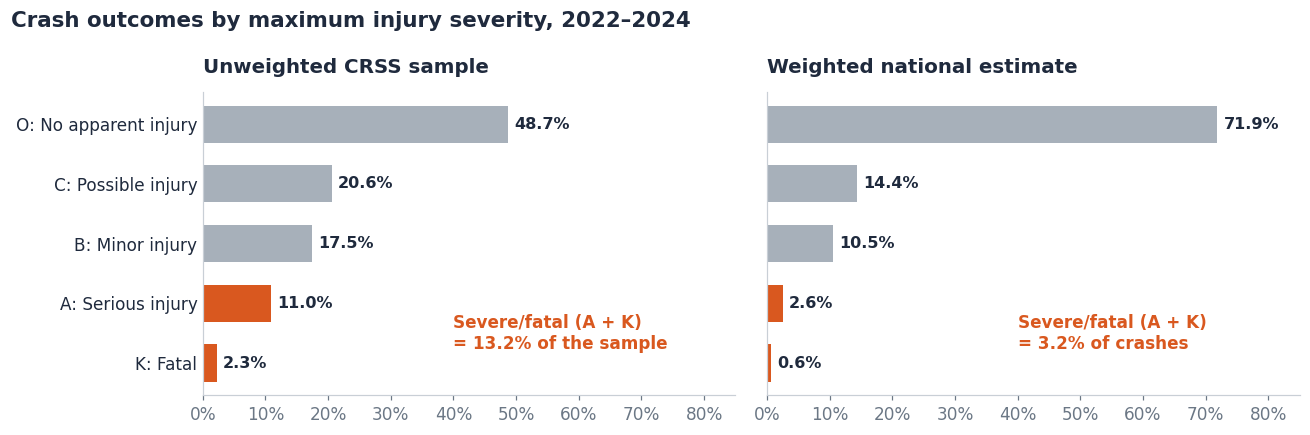

In [10]:
severity_table = (
    df.groupby("severity", observed=True)
      .agg(sample_n=("CASENUM", "size"), weighted_total=("WEIGHT", "sum"))
)
severity_table["sample_pct"] = 100 * severity_table["sample_n"] / severity_table["sample_n"].sum()
severity_table["weighted_pct"] = 100 * severity_table["weighted_total"] / severity_table["weighted_total"].sum()
severity_table["average_annual_crashes"] = severity_table["weighted_total"] / 3
display(severity_table.drop(columns="weighted_total").style.format(
    {"sample_n": "{:,.0f}", "sample_pct": "{:.1f}%", "weighted_pct": "{:.1f}%", "average_annual_crashes": "{:,.0f}"}))

short = ["O: No apparent injury", "C: Possible injury", "B: Minor injury", "A: Serious injury", "K: Fatal"]
sev_colors = [BASE, BASE, BASE, ACCENT, ACCENT]
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, col, ttl in [(axes[0], "sample_pct", "Unweighted CRSS sample"),
                     (axes[1], "weighted_pct", "Weighted national estimate")]:
    bars = ax.barh(short, severity_table[col], color=sev_colors, height=0.62)
    ax.bar_label(bars, fmt="%.1f%%", padding=4, fontsize=10.5, fontweight="bold")
    ax.set_xlim(0, 85)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
    ax.tick_params(axis="y", length=0)
    ax.set_title(ttl)
axes[0].invert_yaxis()
axes[1].text(40, 3.5, f"Severe/fatal (A + K)\n= {severity_table['weighted_pct'].iloc[3:].sum():.1f}% of crashes",
             color=ACCENT, fontsize=11, fontweight="bold", va="center")
axes[0].text(40, 3.5, f"Severe/fatal (A + K)\n= {severity_table['sample_pct'].iloc[3:].sum():.1f}% of the sample",
             color=ACCENT, fontsize=11, fontweight="bold", va="center")
fig.suptitle("Crash outcomes by maximum injury severity, 2022–2024", x=0.01, ha="left", fontweight="bold", fontsize=14)
fig.tight_layout()
save("01_severity_distribution")

About 3.2% of U.S. police-reported crashes are severe or fatal: roughly 194,000
crashes per year. In the raw sample the share is 13.2%, four times higher, because CRSS deliberately
oversamples severe crashes. Using the weights is essential for national conclusions.

### 3.2 Crash volume and severity by year

YEAR,sample_n,crashes_per_year,share_of_crashes_pct,severe_fatal_pct
2022,"53,828","5,918,089",32.5%,3.31%
2023,"49,972","6,124,762",33.6%,3.14%
2024,"51,508","6,167,291",33.9%,3.13%


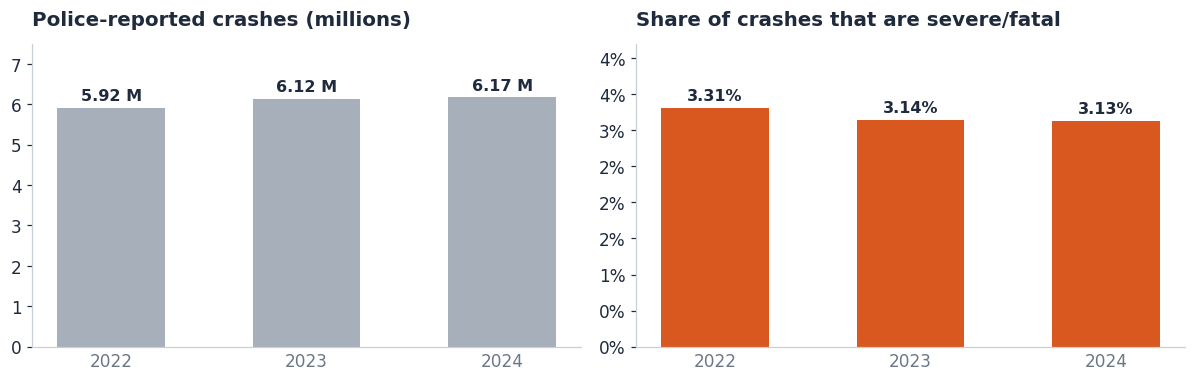

In [11]:
year_table = rate_table(df, "YEAR")
display(show(year_table))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
yrs = year_table["YEAR"].astype(str)
b0 = axes[0].bar(yrs, year_table["crashes_per_year"] / 1e6, color=BASE, width=0.55)
axes[0].bar_label(b0, labels=[f"{v / 1e6:.2f} M" for v in year_table["crashes_per_year"] * 1], padding=3,
                  fontsize=10.5, fontweight="bold")
axes[0].set_ylim(0, 7.5)
axes[0].set_title("Police-reported crashes (millions)")
b1 = axes[1].bar(yrs, year_table["severe_fatal_pct"], color=ACCENT, width=0.55)
axes[1].bar_label(b1, fmt="%.2f%%", padding=3, fontsize=10.5, fontweight="bold")
axes[1].set_ylim(0, 4.2)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
axes[1].set_title("Share of crashes that are severe/fatal")
for ax in axes:
    ax.tick_params(axis="x", length=0)
fig.tight_layout()
save("02_by_year")

Crash volume rose slightly (5.9 → 6.2 million), while the severe/fatal share stayed close to 3.1–3.3% in
every year. The patterns below are therefore pooled across 2022–2024.

### 3.3 Behavioral characteristics: speeding and alcohol

speeding,sample_n,crashes_per_year,share_of_crashes_pct,severe_fatal_pct
No,"132,860","5,234,381",86.2%,2.84%
Yes,"16,118","585,650",9.6%,5.85%
Unknown,"6,330","250,017",4.1%,4.29%


alcohol,sample_n,crashes_per_year,share_of_crashes_pct,severe_fatal_pct
No,"144,657","5,725,088",94.3%,2.82%
Yes,"10,651","344,959",5.7%,9.36%


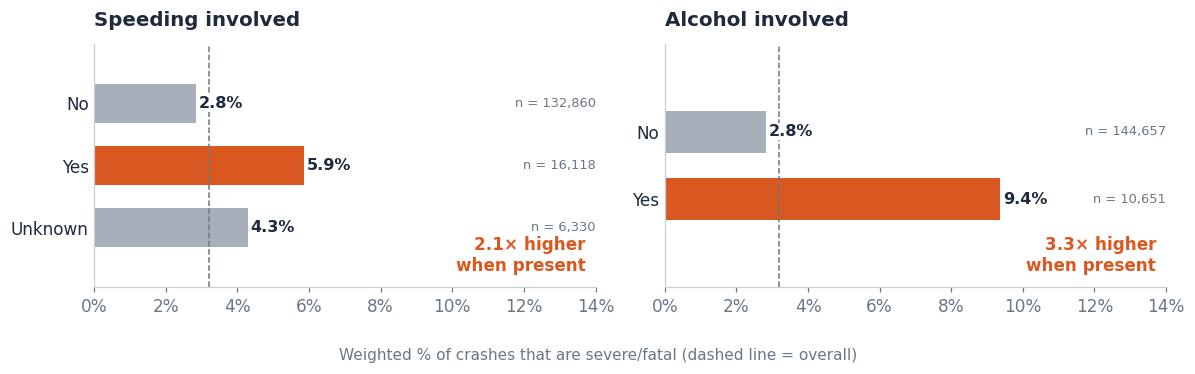

In [12]:
speeding_table = rate_table(df, "speeding")
alcohol_table = rate_table(df, "alcohol")
display(show(speeding_table))
display(show(alcohol_table))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
bar_panel(axes[0], speeding_table, "speeding", "Speeding involved", highlight=("Yes",), xmax=14)
bar_panel(axes[1], alcohol_table, "alcohol", "Alcohol involved", highlight=("Yes",), xmax=14)
for ax, t, g in [(axes[0], speeding_table, "speeding"), (axes[1], alcohol_table, "alcohol")]:
    r = t.set_index(g)["severe_fatal_pct"]
    ax.text(0.98, 0.05, f"{r['Yes'] / r['No']:.1f}× higher\nwhen present", transform=ax.transAxes,
            ha="right", va="bottom", color=ACCENT, fontsize=11, fontweight="bold")
fig.supxlabel("Weighted % of crashes that are severe/fatal (dashed line = overall)", fontsize=10, color=MUTED)
fig.tight_layout()
save("03_speeding_alcohol")

The two behaviors often occur in the same crash, so it helps to look at
the four combinations (crashes with unknown speeding status are left out of this chart).

behavior,sample_n,crashes_per_year,share_of_crashes_pct,severe_fatal_pct
Neither,"124,601","4,960,272",85.2%,2.54%
Speeding only,"14,122","527,085",9.1%,4.96%
Alcohol only,"8,259","274,109",4.7%,8.27%
Both,"1,996","58,564",1.0%,13.87%


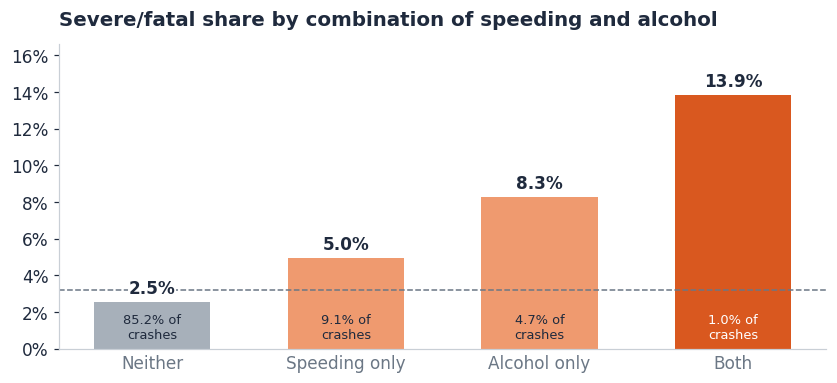

In [13]:
combo_df = df[df["speeding"] != "Unknown"].copy()
combo_df["behavior"] = np.select(
    [(combo_df["speeding"] == "Yes") & (combo_df["alcohol"] == "Yes"),
     combo_df["alcohol"] == "Yes",
     combo_df["speeding"] == "Yes"],
    ["Both", "Alcohol only", "Speeding only"], default="Neither")
combo_df["behavior"] = pd.Categorical(combo_df["behavior"],
                                      categories=["Neither", "Speeding only", "Alcohol only", "Both"])
combo_table = rate_table(combo_df, "behavior")
display(show(combo_table))

fig, ax = plt.subplots(figsize=(9, 3.6))
cols = [BASE, "#ef9a6f", "#ef9a6f", ACCENT]
bars = ax.bar(combo_table["behavior"].astype(str), combo_table["severe_fatal_pct"], color=cols, width=0.6)
for txt in ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=11, fontweight="bold"):
    txt.set_bbox(dict(facecolor="white", edgecolor="none", pad=0.5))
for b, (_, r) in zip(bars, combo_table.iterrows()):
    ax.text(b.get_x() + b.get_width() / 2, 0.4, f"{r['share_of_crashes_pct']:.1f}% of\ncrashes",
            ha="center", va="bottom", fontsize=8.5, color="white" if r["behavior"] == "Both" else INK)
ax.axhline(overall_rate, color=MUTED, ls="--", lw=1)
ax.set_ylim(0, combo_table["severe_fatal_pct"].max() * 1.2)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.tick_params(axis="x", length=0)
ax.set_title("Severe/fatal share by combination of speeding and alcohol")
save("04_speeding_alcohol_combined")

Crashes with both speeding and alcohol are rare (about 1% of crashes), but they are by far the most
severe group: 13.9% are severe/fatal, more than five times the 2.5% for crashes with neither. Each behavior on its own already raises the severe/fatal share well above the 3.2% average.

### 3.4 Time of day and day of week

The top panel shows how many crashes happen each hour, the bottom panel shows how severe they are.

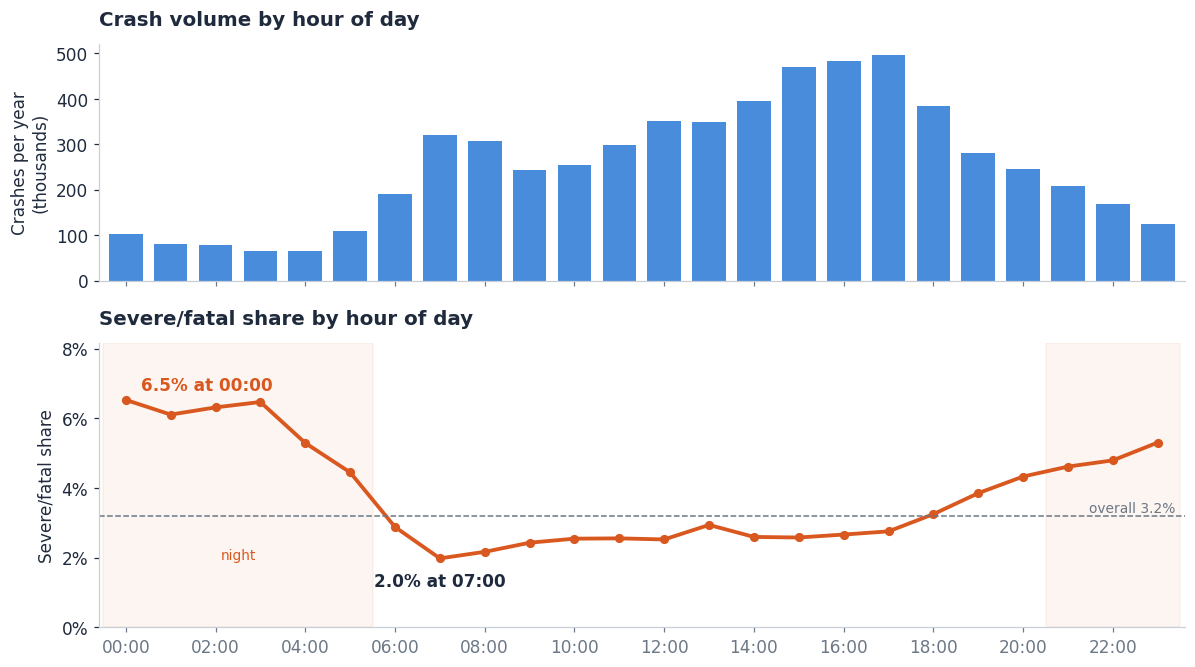

In [14]:
hour_table = rate_table(df, "hour")

fig, axes = plt.subplots(2, 1, figsize=(11, 6.2), sharex=True, gridspec_kw={"height_ratios": [1, 1.2]})
axes[0].bar(hour_table["hour"], hour_table["crashes_per_year"] / 1000, color=BLUE, width=0.75, alpha=0.85)
axes[0].set_ylabel("Crashes per year\n(thousands)")
axes[0].set_title("Crash volume by hour of day")
axes[1].plot(hour_table["hour"], hour_table["severe_fatal_pct"], color=ACCENT, lw=2.5, marker="o", ms=5)
axes[1].axhline(overall_rate, color=MUTED, ls="--", lw=1)
axes[1].text(23.4, overall_rate + 0.12, f"overall {overall_rate:.1f}%", ha="right", color=MUTED, fontsize=9)
peak = hour_table.loc[hour_table["severe_fatal_pct"].idxmax()]
low = hour_table.loc[hour_table["severe_fatal_pct"].idxmin()]
axes[1].annotate(f"{peak['severe_fatal_pct']:.1f}% at {int(peak['hour']):02d}:00", (peak["hour"], peak["severe_fatal_pct"]),
                 xytext=(10, 6), textcoords="offset points", color=ACCENT, fontweight="bold")
axes[1].annotate(f"{low['severe_fatal_pct']:.1f}% at {int(low['hour']):02d}:00", (low["hour"], low["severe_fatal_pct"]),
                 xytext=(0, -18), textcoords="offset points", ha="center", color=INK, fontweight="bold")
axes[1].axvspan(-0.5, 5.5, color=ACCENT, alpha=0.06)
axes[1].axvspan(20.5, 23.5, color=ACCENT, alpha=0.06)
axes[1].text(2.5, axes[1].get_ylim()[0] + 0.2, "night", ha="center", color=ACCENT, fontsize=9)
axes[1].set_ylim(0, hour_table["severe_fatal_pct"].max() * 1.25)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
axes[1].set_ylabel("Severe/fatal share")
axes[1].set_title("Severe/fatal share by hour of day")
axes[1].set_xticks(range(0, 24, 2), [f"{h:02d}:00" for h in range(0, 24, 2)])
axes[1].set_xlim(-0.6, 23.6)
fig.tight_layout()
save("05_by_hour")

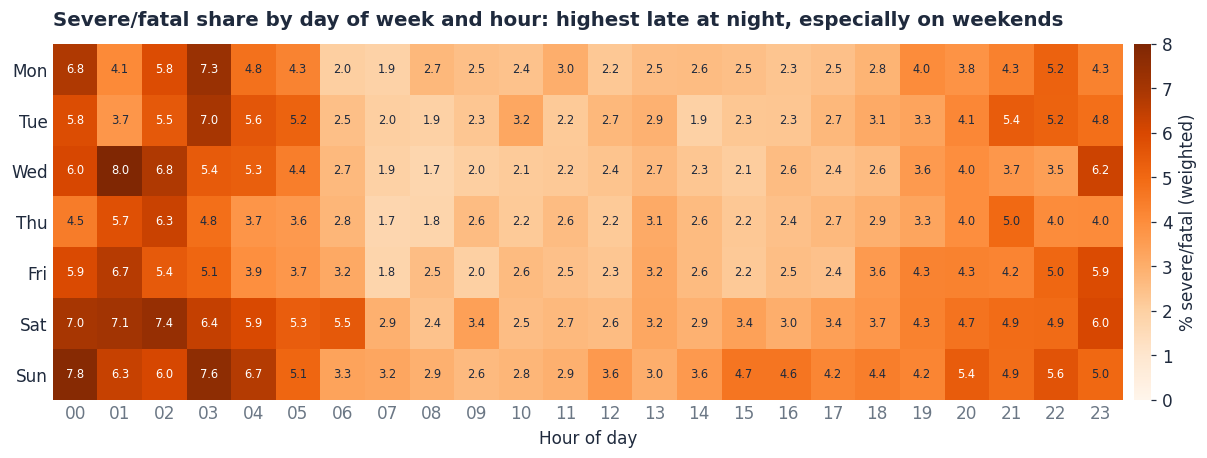

In [15]:
hm = (df.assign(w_sev=df["WEIGHT"] * df["severe_fatal"])
        .groupby(["day_of_week", "hour"], observed=True)[["w_sev", "WEIGHT"]].sum())
heat = (100 * hm["w_sev"] / hm["WEIGHT"]).unstack("hour")

fig, ax = plt.subplots(figsize=(13, 4.2))
im = ax.imshow(heat.values, cmap="Oranges", aspect="auto", vmin=0, vmax=8)
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        v = heat.values[i, j]
        ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=7.5, color="white" if v > 5.2 else INK)
ax.set_xticks(range(24), [f"{h:02d}" for h in range(24)])
ax.set_yticks(range(7), heat.index.astype(str))
ax.set_xlabel("Hour of day")
ax.tick_params(length=0)
for s in ax.spines.values():
    s.set_visible(False)
cb = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.01)
cb.set_label("% severe/fatal (weighted)")
cb.outline.set_visible(False)
ax.set_title("Severe/fatal share by day of week and hour: highest late at night, especially on weekends")
save("06_heatmap_day_hour")

night,sample_n,crashes_per_year,share_of_crashes_pct,severe_fatal_pct
Day/evening,"128,692","5,070,146",83.5%,2.77%
Night,"26,616","999,901",16.5%,5.33%


weekend,sample_n,crashes_per_year,share_of_crashes_pct,severe_fatal_pct
Weekday,"117,061","4,626,802",76.2%,2.88%
Weekend,"38,247","1,443,246",23.8%,4.19%


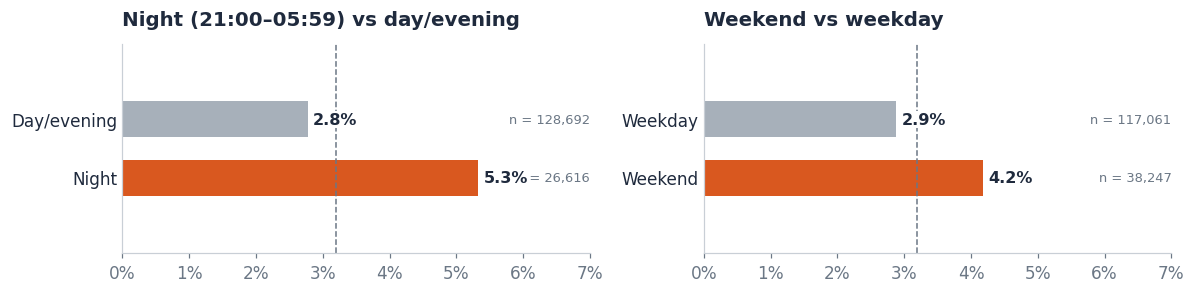

In [16]:
night_table = rate_table(df, "night")
weekend_table = rate_table(df, "weekend")
display(show(night_table))
display(show(weekend_table))

fig, axes = plt.subplots(1, 2, figsize=(11, 2.8))
bar_panel(axes[0], night_table, "night", "Night (21:00–05:59) vs day/evening", highlight=("Night",), xmax=7)
bar_panel(axes[1], weekend_table, "weekend", "Weekend vs weekday", highlight=("Weekend",), xmax=7)
fig.tight_layout()
save("07_night_weekend")

Crash volume peaks in the weekday afternoon rush, but crash severity peaks between midnight and
05:00 and is highest on Friday-to-Sunday nights. Night crashes are almost twice as likely to be severe/fatal
as day/evening crashes.

### 3.5 Environmental and roadway characteristics

lighting,sample_n,crashes_per_year,share_of_crashes_pct,severe_fatal_pct
Daylight,"104,752","4,127,307",68.0%,2.65%
Dawn/Dusk,"6,574","263,236",4.3%,3.16%
Dark - Lighted,"26,382","970,901",16.0%,4.00%
Dark - Not Lighted,"15,866","630,032",10.4%,5.55%
Dark - Unknown Lighting,"1,734","78,571",1.3%,3.07%


weather,sample_n,crashes_per_year,share_of_crashes_pct,severe_fatal_pct
Clear,"118,512","4,555,746",75.1%,3.33%
Cloudy,"20,411","817,901",13.5%,3.01%
Rain,"12,896","534,753",8.8%,2.51%
Snow/ice,"2,692","128,596",2.1%,1.88%
Other,797,"33,051",0.5%,4.79%


urbanicity,sample_n,crashes_per_year,share_of_crashes_pct,severe_fatal_pct
Urban,"116,895","4,494,115",74.0%,2.88%
Rural,"38,413","1,575,933",26.0%,4.10%


junction,sample_n,crashes_per_year,share_of_crashes_pct,severe_fatal_pct
Non-junction,"61,138","2,493,693",41.1%,3.91%
Intersection,"74,897","2,799,962",46.1%,2.76%
Driveway,"9,801","391,382",6.4%,2.22%
Interchange/ramp,"3,992","162,116",2.7%,3.43%
Other,"5,480","222,895",3.7%,2.16%


interstate,sample_n,crashes_per_year,share_of_crashes_pct,severe_fatal_pct
No,"140,097","5,448,895",89.8%,3.22%
Yes,"15,198","620,658",10.2%,2.97%
Unknown,13,495,0.0%,7.60%


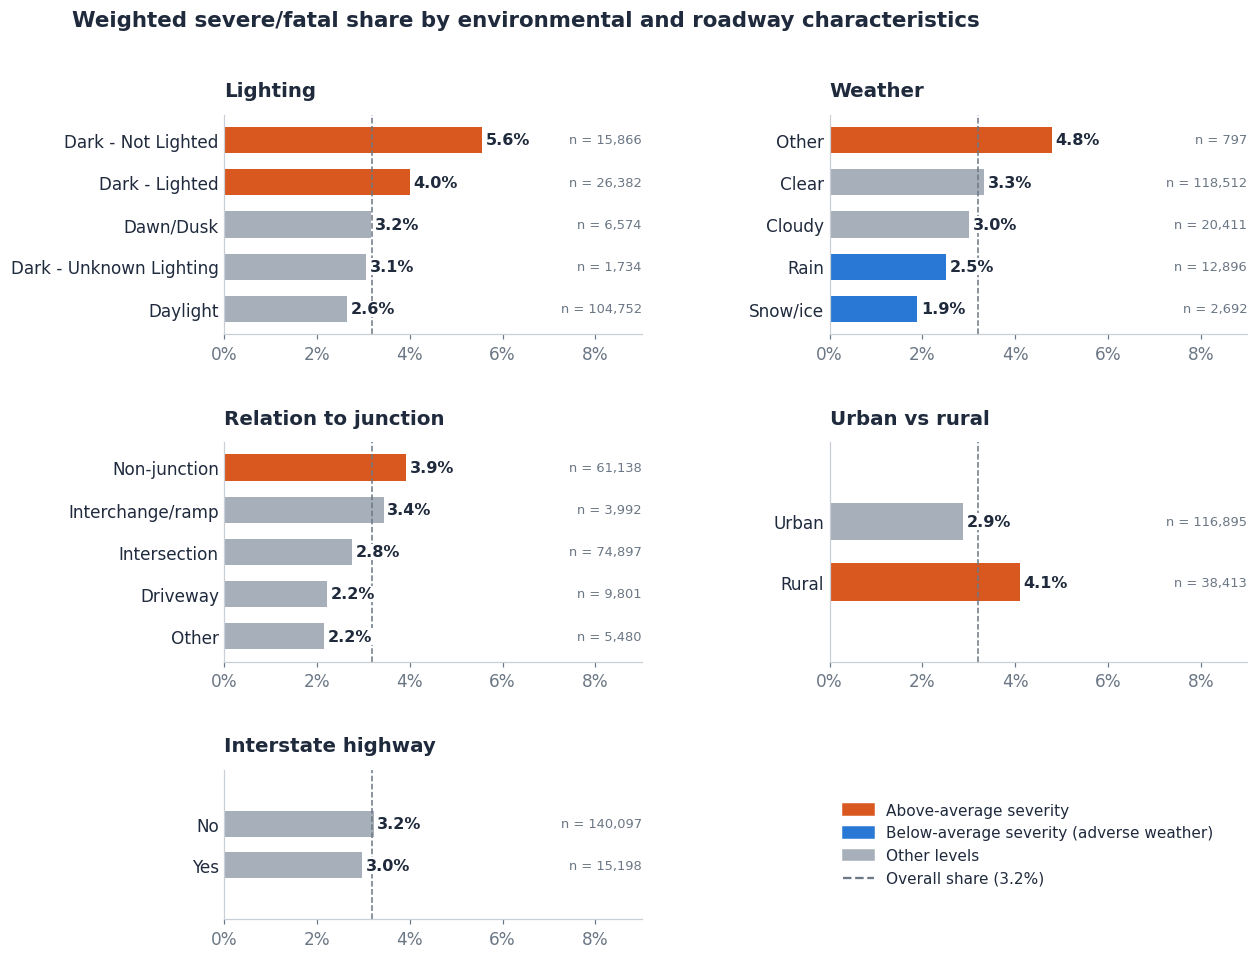

In [17]:
lighting_table = rate_table(df, "lighting")
weather_table = rate_table(df, "weather")
urban_table = rate_table(df, "urbanicity")
junction_table = rate_table(df, "junction")
interstate_table = rate_table(df, "interstate")
for t in [lighting_table, weather_table, urban_table, junction_table, interstate_table]:
    display(show(t))

fig = plt.figure(figsize=(12, 9.5))
gs = fig.add_gridspec(3, 2, height_ratios=[1.1, 1.1, 0.75], hspace=0.55, wspace=0.45)
bar_panel(fig.add_subplot(gs[0, 0]), lighting_table, "lighting", "Lighting", sort=True,
          highlight=("Dark - Not Lighted", "Dark - Lighted"), xmax=9)
bar_panel(fig.add_subplot(gs[0, 1]), weather_table, "weather", "Weather", sort=True,
          highlight=("Other",), protective=("Rain", "Snow/ice"), xmax=9)
bar_panel(fig.add_subplot(gs[1, 0]), junction_table, "junction", "Relation to junction", sort=True,
          highlight=("Non-junction",), xmax=9)
bar_panel(fig.add_subplot(gs[1, 1]), urban_table, "urbanicity", "Urban vs rural", highlight=("Rural",), xmax=9)
bar_panel(fig.add_subplot(gs[2, 0]), interstate_table[interstate_table["interstate"] != "Unknown"],
          "interstate", "Interstate highway", xmax=9)
legend_ax = fig.add_subplot(gs[2, 1])
legend_ax.axis("off")
legend_ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=ACCENT, label="Above-average severity"),
                          plt.Rectangle((0, 0), 1, 1, color=BLUE, label="Below-average severity (adverse weather)"),
                          plt.Rectangle((0, 0), 1, 1, color=BASE, label="Other levels"),
                          Line2D([], [], color=MUTED, ls="--", label=f"Overall share ({overall_rate:.1f}%)")],
                 loc="center left", fontsize=10)
fig.suptitle("Weighted severe/fatal share by environmental and roadway characteristics",
             x=0.01, ha="left", fontweight="bold", fontsize=14)
save("08_environment_roadway")

- **Lighting:** severity rises from daylight (2.6%) to dark-but-lighted roads (4.0%) and dark, unlighted roads (5.6%).
- **Weather:** rain and snow/ice crashes are less often severe than clear-weather crashes, plausibly because
  drivers slow down in poor conditions. The small "Other" group (fog, wind) is the exception.
- **Roadway:** rural crashes and crashes away from junctions are more often severe. Interstate crashes are
  not more severe than others.

### 3.6 How do severe/fatal crashes differ from other crashes?

The chart compares the **share of crashes with each characteristic** among severe/fatal crashes and among
all other crashes (weighted). A large gap means the characteristic is over-represented in severe crashes.

characteristic,% of severe/fatal crashes,% of other crashes,severe/fatal % if present,severe/fatal % if absent,ratio (present ÷ absent)
Alcohol involved,16.7,5.3,9.4,2.8,3.32
Speeding involved,17.7,9.4,5.9,2.9,2.01
Night (21:00–05:59),27.5,16.1,5.3,2.8,1.92
"Dark, not lighted",18.1,10.1,5.6,2.9,1.90
Non-junction,50.3,40.8,3.9,2.7,1.45
Weekend,31.2,23.5,4.2,2.9,1.45
Rural,33.3,25.7,4.1,2.9,1.43
Interstate,9.5,10.2,3.0,3.2,0.92
Rain or snow/ice,8.2,11.0,2.4,3.3,0.73


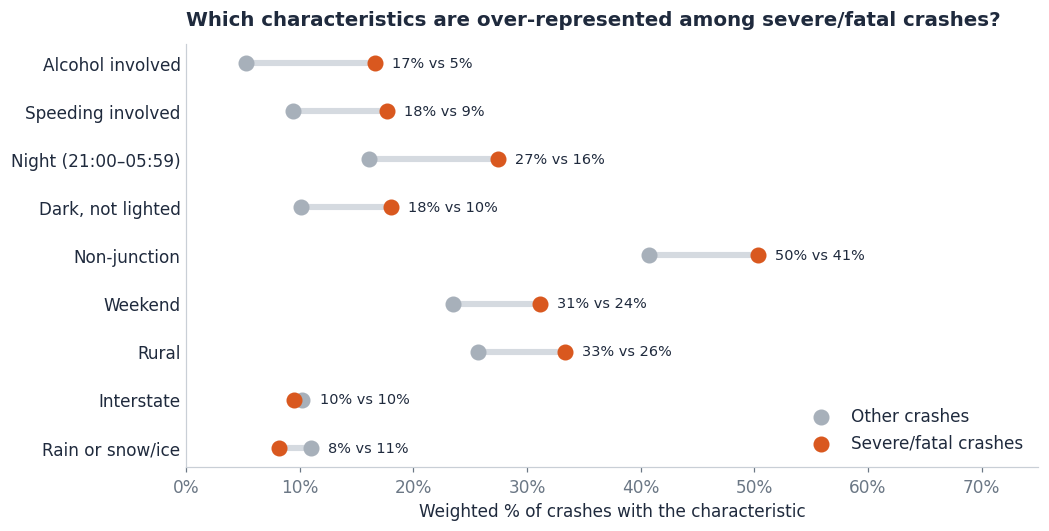

In [18]:
indicators = {
    "Speeding involved": df["speeding"] == "Yes",
    "Alcohol involved": df["alcohol"] == "Yes",
    "Night (21:00–05:59)": df["night"] == "Night",
    "Weekend": df["weekend"] == "Weekend",
    "Dark, not lighted": df["lighting"] == "Dark - Not Lighted",
    "Rain or snow/ice": df["weather"].isin(["Rain", "Snow/ice"]),
    "Rural": df["urbanicity"] == "Rural",
    "Non-junction": df["junction"] == "Non-junction",
    "Interstate": df["interstate"] == "Yes",
}

profile_rows = []
for name, mask in indicators.items():
    ka, other = df["severe_fatal"] == 1, df["severe_fatal"] == 0
    present_rate = 100 * weighted_rate(df[mask])
    absent_rate = 100 * weighted_rate(df[~mask])
    profile_rows.append({
        "characteristic": name,
        "% of severe/fatal crashes": 100 * df.loc[ka & mask, "WEIGHT"].sum() / df.loc[ka, "WEIGHT"].sum(),
        "% of other crashes": 100 * df.loc[other & mask, "WEIGHT"].sum() / df.loc[other, "WEIGHT"].sum(),
        "severe/fatal % if present": present_rate,
        "severe/fatal % if absent": absent_rate,
        "ratio (present ÷ absent)": present_rate / absent_rate,
    })
profile = pd.DataFrame(profile_rows).sort_values("ratio (present ÷ absent)", ascending=False).reset_index(drop=True)
display(profile.style.format({c: "{:.1f}" for c in profile.columns[1:5]} | {"ratio (present ÷ absent)": "{:.2f}"})
               .hide(axis="index"))

p = profile.iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 5))
y = np.arange(len(p))
ax.hlines(y, p["% of other crashes"], p["% of severe/fatal crashes"], color="#d5dae0", lw=4, zorder=1)
ax.scatter(p["% of other crashes"], y, color=BASE, s=90, zorder=2, label="Other crashes")
ax.scatter(p["% of severe/fatal crashes"], y, color=ACCENT, s=90, zorder=3, label="Severe/fatal crashes")
for yi, (_, r) in zip(y, p.iterrows()):
    ax.text(max(r["% of severe/fatal crashes"], r["% of other crashes"]) + 1.5, yi,
            f"{r['% of severe/fatal crashes']:.0f}% vs {r['% of other crashes']:.0f}%", va="center", fontsize=9.5, color=INK)
ax.set_yticks(y, p["characteristic"])
ax.tick_params(axis="y", length=0)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.set_xlim(0, 75)
ax.set_xlabel("Weighted % of crashes with the characteristic")
ax.legend(loc="lower right")
ax.set_title("Which characteristics are over-represented among severe/fatal crashes?")
save("09_profile_severe_vs_other")

For example, alcohol is involved in about 17% of severe/fatal crashes but only about 5% of other crashes.

### 3.7 Ranking the characteristics (unadjusted)

The ratio below divides the severe/fatal share when a characteristic is present by the share when it is
absent. This is an unadjusted comparison: it does not account for the fact that these characteristics
overlap. The regression in Section 4 does.

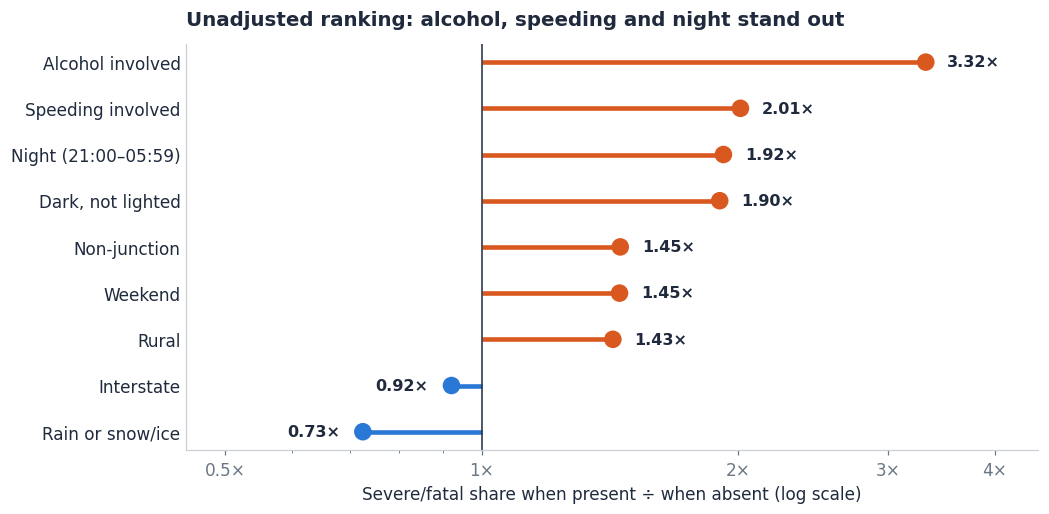

In [19]:
r = profile.sort_values("ratio (present ÷ absent)")
fig, ax = plt.subplots(figsize=(10, 4.8))
y = np.arange(len(r))
colors = [ACCENT if v > 1 else BLUE for v in r["ratio (present ÷ absent)"]]
ax.hlines(y, 1, r["ratio (present ÷ absent)"], color=colors, lw=3)
ax.scatter(r["ratio (present ÷ absent)"], y, color=colors, s=110, zorder=3)
for yi, v in zip(y, r["ratio (present ÷ absent)"]):
    ax.text(v * (1.06 if v > 1 else 0.94), yi, f"{v:.2f}×", va="center", ha="left" if v > 1 else "right",
            fontsize=10.5, fontweight="bold")
ax.axvline(1, color=INK, lw=1)
ax.set_xscale("log")
ax.set_xticks([0.5, 1, 2, 3, 4], ["0.5×", "1×", "2×", "3×", "4×"])
ax.xaxis.set_minor_formatter(mtick.NullFormatter())
ax.set_xlim(0.45, 4.5)
ax.set_yticks(y, r["characteristic"])
ax.tick_params(axis="y", length=0)
ax.set_xlabel("Severe/fatal share when present ÷ when absent (log scale)")
ax.set_title("Unadjusted ranking: alcohol, speeding and night stand out")
save("10_unadjusted_ranking")

### 3.8 Are the patterns stable across years?

YEAR,2022,2023,2024
characteristic,,,
Alcohol involved,3.31,3.31,3.33
"Dark, not lighted",1.88,2.05,1.79
Night (21:00–05:59),1.90,1.95,1.92
Rain or snow/ice,0.72,0.74,0.71
Rural,1.50,1.50,1.29
Speeding involved,2.05,1.98,2.01


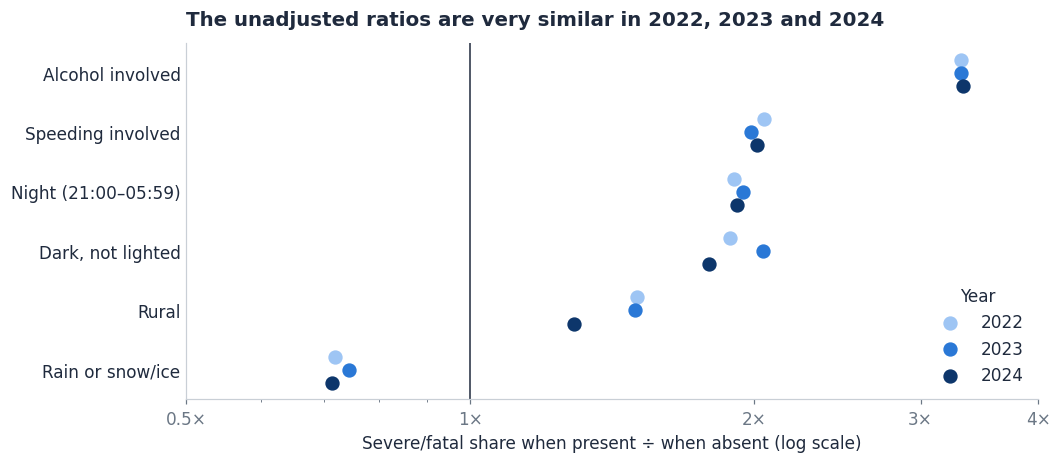

In [20]:
stab_rows = []
for yr, g in df.groupby("YEAR"):
    for name in ["Alcohol involved", "Speeding involved", "Night (21:00–05:59)", "Dark, not lighted", "Rural",
                 "Rain or snow/ice"]:
        mask = indicators[name].loc[g.index]
        stab_rows.append({"YEAR": yr, "characteristic": name,
                          "ratio": weighted_rate(g[mask]) / weighted_rate(g[~mask])})
stab = pd.DataFrame(stab_rows)
display(stab.pivot(index="characteristic", columns="YEAR", values="ratio").round(2))

fig, ax = plt.subplots(figsize=(10, 4.2))
names = stab["characteristic"].unique()
yb = np.arange(len(names))[::-1]
for i, (yr, c) in enumerate(zip([2022, 2023, 2024], ["#9ec5f4", "#2a78d6", "#0d366b"])):
    s = stab[stab["YEAR"] == yr].set_index("characteristic").loc[names]
    ax.scatter(s["ratio"], yb + (1 - i) * 0.22, color=c, s=70, label=str(yr), zorder=3)
ax.axvline(1, color=INK, lw=1)
ax.set_xscale("log")
ax.set_xticks([0.5, 1, 2, 3, 4], ["0.5×", "1×", "2×", "3×", "4×"])
ax.xaxis.set_minor_formatter(mtick.NullFormatter())
ax.set_yticks(yb, names)
ax.tick_params(axis="y", length=0)
ax.set_xlabel("Severe/fatal share when present ÷ when absent (log scale)")
ax.legend(title="Year", loc="lower right")
ax.set_title("The unadjusted ratios are very similar in 2022, 2023 and 2024")
save("11_stability_by_year")

### 3.9 EDA takeaways

1. **Severe/fatal crashes are rare:** 3.2% of crashes nationally (about 194,000 per year), but 13% of the sample.
2. **Behavior matters most:** alcohol (≈3.3× higher share) and speeding (≈2.1×) show the largest differences,
   and crashes with both are the most severe of all.
3. **Night and darkness matter:** severity peaks after midnight, especially on weekends, and on unlighted roads.
4. **Bad weather is not more severe:** rain and snow/ice crashes are less often severe than clear-weather crashes.
5. **Roadway:** rural and non-junction crashes are more often severe, interstate crashes are not.
6. **Stable over time:** these patterns barely change between 2022 and 2024.

Because these characteristics overlap (for example, alcohol-involved crashes happen mostly at night),
the next section estimates them together in one model.

## 4. Weighted logistic regression

We will explore which characteristics remain associated
with a severe/fatal outcome when the others are held constant.

**Plan**

1. Prepare the model data and check that every category has enough severe/fatal crashes.
2. Check which predictors overlap too much to include together.
3. Estimate crude (one-predictor) odds ratios.
4. Build the model in three steps (behavior → Add time → Add environment/roadway) to see how the estimates change.
5. Interpret the final adjusted odds ratios.
6. Translate the model into predicted probabilities for a few example crashes.

### 4.1 Prepare the model data

Crashes with unknown speeding status or unknown interstate status are excluded from the model,
because "unknown" is not a meaningful category to interpret.

In [21]:
excluded = df[(df["speeding"] == "Unknown") | (df["interstate"] == "Unknown")]
print(f"Excluded from the model: {len(excluded):,} crashes ({len(excluded) / len(df):.1%} of the sample)")
print(f"Weighted severe/fatal share among excluded crashes: {100 * weighted_rate(excluded):.2f}% "
      f"(vs {overall_rate:.2f}% overall)")

model_df = df[(df["speeding"] != "Unknown") & (df["interstate"] != "Unknown")].copy()

# Remove unused categories after filtering
for col in ["speeding", "alcohol", "night", "weekend", "lighting", "weather",
            "urbanicity", "junction", "interstate", "year"]:
    model_df[col] = model_df[col].cat.remove_unused_categories()

# Normalize survey weights so the mean weight is 1 (does not change the estimates)
model_df["weight_norm"] = model_df["WEIGHT"] / model_df["WEIGHT"].mean()

print(f"Model observations: {len(model_df):,}  |  severe/fatal crashes in the sample: {model_df['severe_fatal'].sum():,}")

Excluded from the model: 6,342 crashes (4.1% of the sample)
Weighted severe/fatal share among excluded crashes: 4.29% (vs 3.19% overall)
Model observations: 148,966  |  severe/fatal crashes in the sample: 19,470


**Predictors and reference groups.** Each odds ratio compares a level to the reference group of its variable.

| Group | Variable | Reference group | Other levels |
|---|---|---|---|
| Behavioral | Speeding | No | Yes |
| Behavioral | Alcohol | No | Yes |
| Time | Night (21:00–05:59) | Day/evening | Night |
| Time | Weekend | Weekday | Weekend |
| Environment | Weather | Clear | Cloudy, Rain, Snow/ice, Other |
| Roadway | Urban/rural | Urban | Rural |
| Roadway | Junction | Non-junction | Intersection, Driveway, Interchange/ramp, Other |
| Roadway | Interstate | No | Yes |
| Control | Year | 2022 | 2023, 2024 |

**Enough events in every category?** A rule of thumb is that each level should contain at least a few dozen
outcome events, very small cells give unstable odds ratios.

In [22]:
PREDICTORS = ["speeding", "alcohol", "night", "weekend", "weather", "urbanicity", "junction", "interstate", "year"]

event_rows = []
for v in PREDICTORS:
    for lvl, g in model_df.groupby(v, observed=True):
        event_rows.append({"variable": v, "level": str(lvl), "crashes": len(g),
                           "severe_fatal_events": int(g["severe_fatal"].sum())})
events = pd.DataFrame(event_rows)
print("Smallest number of severe/fatal events in any level:", events["severe_fatal_events"].min())
display(events.sort_values("severe_fatal_events").head(6).style.hide(axis="index"))

Smallest number of severe/fatal events in any level: 141


variable,level,crashes,severe_fatal_events
weather,Other,760,141
weather,Snow/ice,2558,224
junction,Other,5195,520
junction,Interchange/ramp,3825,607
junction,Driveway,9467,867
weather,Rain,12378,1383


Every level has well over 100 severe/fatal crashes in the sample, so all categories can be estimated.

### 4.2 Check for overlapping predictors: night vs. lighting

Night and lighting describe almost the same thing. The table shows the weighted lighting distribution
within day/evening and night crashes.

In [23]:
overlap = pd.crosstab(model_df["night"], model_df["lighting"], values=model_df["WEIGHT"],
                      aggfunc="sum", normalize="index") * 100
display(overlap.round(1))

lighting,Daylight,Dawn/Dusk,Dark - Lighted,Dark - Not Lighted,Dark - Unknown Lighting
night,,,,,
Day/evening,81.0,4.6,8.5,5.4,0.5
Night,2.3,3.0,53.1,36.6,5.0


Almost all night crashes happen in the dark, so putting both variables in the model would split one signal
between two overlapping variables and make both harder to interpret. The model uses night. Lighting is kept in the EDA.

### 4.3 Crude (unadjusted) odds ratios

First, a separate weighted logistic regression for each predictor alone.

**Standard errors:** Crashes in CRSS are sampled in geographic clusters (primary sampling units, `PSU_VAR`),
and crashes from the same area tend to be similar. All models therefore use statsmodels' built-in
cluster-robust standard errors by PSU (`cov_type="cluster"`). This is one argument in `.fit()`. It does not
change the odds ratios, and it gives more honest (wider) confidence intervals than the default.

In [24]:
def fit_weighted_logit(formula, data):
    return smf.glm(
        formula=formula,
        data=data,
        family=sm.families.Binomial(),
        var_weights=data["weight_norm"],
    ).fit(cov_type="cluster", cov_kwds={"groups": data["PSU_VAR"]})


def or_table_from(model):
    ci = model.conf_int()
    t = pd.DataFrame({
        "term": model.params.index,
        "odds_ratio": np.exp(model.params.values),
        "ci_low": np.exp(ci[0].values),
        "ci_high": np.exp(ci[1].values),
        "p_value": model.pvalues.values,
    })
    return t[t["term"] != "Intercept"].reset_index(drop=True)


pretty_names = {
    "C(speeding)[T.Yes]": "Speeding: Yes vs No",
    "C(alcohol)[T.Yes]": "Alcohol: Yes vs No",
    "C(night)[T.Night]": "Night vs day/evening",
    "C(weekend)[T.Weekend]": "Weekend vs weekday",
    "C(weather)[T.Cloudy]": "Weather: Cloudy vs Clear",
    "C(weather)[T.Rain]": "Weather: Rain vs Clear",
    "C(weather)[T.Snow/ice]": "Weather: Snow/ice vs Clear",
    "C(weather)[T.Other]": "Weather: Other vs Clear",
    "C(urbanicity)[T.Rural]": "Rural vs Urban",
    "C(junction)[T.Intersection]": "Intersection vs non-junction",
    "C(junction)[T.Driveway]": "Driveway vs non-junction",
    "C(junction)[T.Interchange/ramp]": "Interchange/ramp vs non-junction",
    "C(junction)[T.Other]": "Other junction vs non-junction",
    "C(interstate)[T.Yes]": "Interstate: Yes vs No",
    "C(year)[T.2023]": "2023 vs 2022",
    "C(year)[T.2024]": "2024 vs 2022",
}

crude = pd.concat([or_table_from(fit_weighted_logit(f"severe_fatal ~ C({v})", model_df)) for v in PREDICTORS],
                  ignore_index=True)
crude["comparison"] = crude["term"].map(pretty_names)
display(crude[["comparison", "odds_ratio", "ci_low", "ci_high", "p_value"]].round(3))

/opt/anaconda3/envs/geoenv/lib/python3.11/site-packages/statsmodels/genmod/generalized_linear_model.py:1488: SpecificationWarning: cov_type not fully supported with var_weights
  glm_results = GLMResults(
/opt/anaconda3/envs/geoenv/lib/python3.11/site-packages/statsmodels/genmod/generalized_linear_model.py:1488: SpecificationWarning: cov_type not fully supported with var_weights
  glm_results = GLMResults(
/opt/anaconda3/envs/geoenv/lib/python3.11/site-packages/statsmodels/genmod/generalized_linear_model.py:1488: SpecificationWarning: cov_type not fully supported with var_weights
  glm_results = GLMResults(
/opt/anaconda3/envs/geoenv/lib/python3.11/site-packages/statsmodels/genmod/generalized_linear_model.py:1488: SpecificationWarning: cov_type not fully supported with var_weights
  glm_results = GLMResults(
/opt/anaconda3/envs/geoenv/lib/python3.11/site-packages/statsmodels/genmod/generalized_linear_model.py:1488: SpecificationWarning: cov_type not fully supported with var_weights
  g

,comparison,odds_ratio,ci_low,ci_high,p_value
0,Speeding: Yes vs No,2.125,1.746,2.586,0.000
1,Alcohol: Yes vs No,3.575,3.060,4.177,0.000
2,Night vs day/evening,1.977,1.788,2.186,0.000
3,Weekend vs weekday,1.479,1.406,1.554,0.000
4,Weather: Cloudy vs Clear,0.908,0.826,0.999,0.048
5,Weather: Rain vs Clear,0.745,0.671,0.826,0.000
6,Weather: Snow/ice vs Clear,0.563,0.453,0.700,0.000
7,Weather: Other vs Clear,1.481,1.184,1.851,0.001
8,Rural vs Urban,1.455,1.194,1.773,0.000
9,Intersection vs non-junction,0.701,0.624,0.787,0.000


### 4.4 Build the model in three steps

| Model | Predictors |
|---|---|
| **M1 – Behavioral** | speeding, alcohol |
| **M2 – Add Time** | M1 + night, weekend |
| **M3 – Full** | M2 + weather, urban/rural, junction, interstate, year |

If an odds ratio shrinks a lot from one step to the next, part of its crude association was really due to the
variables added in that step.

In [25]:
formulas = {
    "M1 Behavioral": "severe_fatal ~ C(speeding) + C(alcohol)",
    "M2 + Time": "severe_fatal ~ C(speeding) + C(alcohol) + C(night) + C(weekend)",
    "M3 Full": ("severe_fatal ~ C(speeding) + C(alcohol) + C(night) + C(weekend) + C(weather) + "
                "C(urbanicity) + C(junction) + C(interstate) + C(year)"),
}
models = {name: fit_weighted_logit(f, model_df) for name, f in formulas.items()}
null_model = fit_weighted_logit("severe_fatal ~ 1", model_df)

step_terms = ["C(speeding)[T.Yes]", "C(alcohol)[T.Yes]", "C(night)[T.Night]", "C(weekend)[T.Weekend]",
              "C(urbanicity)[T.Rural]", "C(weather)[T.Snow/ice]"]
step = pd.DataFrame(index=[pretty_names[t] for t in step_terms])
step.insert(0, "Crude", crude.set_index("term").loc[step_terms, "odds_ratio"].values)
for name, m in models.items():
    step[name] = [np.exp(m.params[t]) if t in m.params else np.nan for t in step_terms]

fit_stats = pd.DataFrame({
    name: {"Parameters": len(m.params),
           "McFadden pseudo-R²": 1 - m.llf / null_model.llf,
           "Converged": m.converged}
    for name, m in models.items()
})
print("Odds ratios as predictors are added:")
display(step.round(2).style.format("{:.2f}", na_rep="—"))
display(fit_stats)

/opt/anaconda3/envs/geoenv/lib/python3.11/site-packages/statsmodels/genmod/generalized_linear_model.py:1488: SpecificationWarning: cov_type not fully supported with var_weights
  glm_results = GLMResults(
/opt/anaconda3/envs/geoenv/lib/python3.11/site-packages/statsmodels/genmod/generalized_linear_model.py:1488: SpecificationWarning: cov_type not fully supported with var_weights
  glm_results = GLMResults(


Odds ratios as predictors are added:


/opt/anaconda3/envs/geoenv/lib/python3.11/site-packages/statsmodels/genmod/generalized_linear_model.py:1488: SpecificationWarning: cov_type not fully supported with var_weights
  glm_results = GLMResults(
/opt/anaconda3/envs/geoenv/lib/python3.11/site-packages/statsmodels/genmod/generalized_linear_model.py:1488: SpecificationWarning: cov_type not fully supported with var_weights
  glm_results = GLMResults(


,Crude,M1 Behavioral,M2 + Time,M3 Full
Speeding: Yes vs No,2.12,1.96,1.89,2.00
Alcohol: Yes vs No,3.58,3.36,2.87,2.77
Night vs day/evening,1.98,—,1.55,1.48
Weekend vs weekday,1.48,—,1.27,1.26
Rural vs Urban,1.45,—,—,1.41
Weather: Snow/ice vs Clear,0.56,—,—,0.41


,M1 Behavioral,M2 + Time,M3 Full
Parameters,3,5,17
McFadden pseudo-R²,0.024537,0.029905,0.037061
Converged,True,True,True


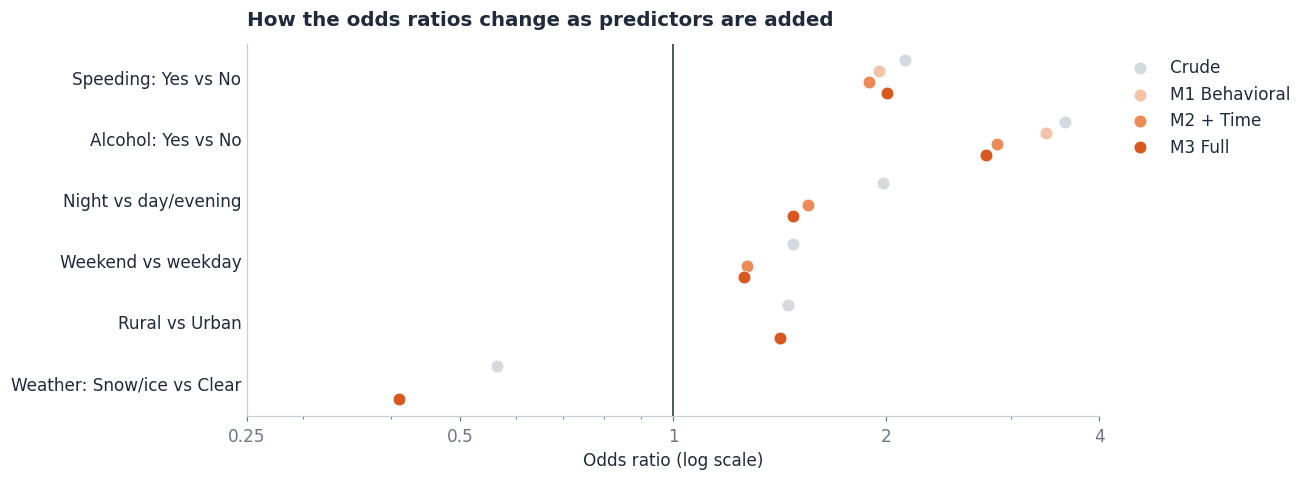

In [26]:
fig, ax = plt.subplots(figsize=(10, 4.4))
cols = ["Crude", "M1 Behavioral", "M2 + Time", "M3 Full"]
shades = ["#d5dae0", "#f5c3a7", "#ec8a58", ACCENT]
y = np.arange(len(step))[::-1]
for i, (c, sh) in enumerate(zip(cols, shades)):
    ax.scatter(step[c], y + (1.5 - i) * 0.18, color=sh, s=70, label=c, zorder=3, edgecolor="white", linewidth=0.5)
ax.axvline(1, color=INK, lw=1)
ax.set_xscale("log")
ax.set_xticks([0.25, 0.5, 1, 2, 4], ["0.25", "0.5", "1", "2", "4"])
ax.xaxis.set_minor_formatter(mtick.NullFormatter())
ax.set_yticks(y, step.index)
ax.tick_params(axis="y", length=0)
ax.set_xlabel("Odds ratio (log scale)")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1))
ax.set_title("How the odds ratios change as predictors are added")
save("12_model_building")

**Reading the steps.**
- **Alcohol and speeding** stay large in every model. Their crude associations are not explained away by time
  of day or the road environment.
- **Night** shrinks once alcohol and speeding are in the model: part of the night effect reflects who is
  driving and how at night. A clear night association still remains.
- **Weekend** shrinks from 1.48 to about 1.26 once night is added: weekend crashes are more severe partly
  because more of them happen at night, but a smaller weekend association remains.
- **Rural** and **snow/ice** keep their associations in the full model.

### 4.5 Final model (M3): adjusted odds ratios

In [27]:
final = models["M3 Full"]
print(f"Observations: {int(final.nobs):,} | Converged: {final.converged} | "
      f"McFadden pseudo-R²: {1 - final.llf / null_model.llf:.3f} | PSU clusters: {model_df['PSU_VAR'].nunique()}")

or_table = or_table_from(final)
or_table["comparison"] = or_table["term"].map(pretty_names)
or_table["change_in_odds"] = (or_table["odds_ratio"] - 1) * 100
or_table["significant (p<0.05)"] = np.where(or_table["p_value"] < 0.05, "Yes", "No")
or_table.to_csv(PROC / "logistic_regression_odds_ratios.csv", index=False)

display(
    or_table[["comparison", "odds_ratio", "ci_low", "ci_high", "change_in_odds", "p_value", "significant (p<0.05)"]]
    .style.format({"odds_ratio": "{:.2f}", "ci_low": "{:.2f}", "ci_high": "{:.2f}",
                   "change_in_odds": "{:+.0f}%", "p_value": "{:.3f}"})
    .hide(axis="index")
)

Observations: 148,966 | Converged: True | McFadden pseudo-R²: 0.037 | PSU clusters: 67


comparison,odds_ratio,ci_low,ci_high,change_in_odds,p_value,significant (p<0.05)
Speeding: Yes vs No,2.00,1.67,2.40,+100%,0.000,Yes
Alcohol: Yes vs No,2.77,2.41,3.17,+177%,0.000,Yes
Night vs day/evening,1.48,1.34,1.63,+48%,0.000,Yes
Weekend vs weekday,1.26,1.21,1.32,+26%,0.000,Yes
Weather: Cloudy vs Clear,0.94,0.87,1.03,-6%,0.178,No
Weather: Rain vs Clear,0.69,0.62,0.76,-31%,0.000,Yes
Weather: Snow/ice vs Clear,0.41,0.34,0.50,-59%,0.000,Yes
Weather: Other vs Clear,1.13,0.90,1.40,+13%,0.290,No
Rural vs Urban,1.41,1.20,1.67,+41%,0.000,Yes
Intersection vs non-junction,0.81,0.72,0.91,-19%,0.000,Yes


**Checking the standard errors against the full CRSS design:** CRSS documentation describes variance estimation
with both sampling strata (`PSUSTRAT`) and primary sampling units (`PSU_VAR`). The cell below recomputes the
standard errors of the final model by Taylor-series linearization with strata and PSUs, and uses a
*t* distribution with design degrees of freedom (#PSUs − #strata). The odds ratios are unchanged, only the
uncertainty around them is recalculated.

In [28]:
from scipy import stats
from scipy.special import expit

X = final.model.exog
y = final.model.endog
w = model_df["weight_norm"].to_numpy()
b = final.params.to_numpy()
p = expit(X @ b)

bread = np.linalg.inv((X * (w * p * (1 - p))[:, None]).T @ X)      # inverse weighted information matrix
scores = pd.DataFrame(X * (w * (y - p))[:, None])                   # each crash's weighted score contribution
scores["stratum"] = model_df["PSUSTRAT"].to_numpy()
scores["psu"] = model_df["PSU_VAR"].to_numpy()
psu_totals = scores.groupby(["stratum", "psu"]).sum()

meat = np.zeros_like(bread)
for _, g in psu_totals.groupby(level="stratum"):                    # PSUs vary around their own stratum's mean
    n_h = len(g)
    if n_h > 1:
        dev = g.to_numpy() - g.to_numpy().mean(axis=0)
        meat += n_h / (n_h - 1) * dev.T @ dev

se_design = np.sqrt(np.diag(bread @ meat @ bread))
design_df = model_df["PSU_VAR"].nunique() - model_df["PSUSTRAT"].nunique()
t_crit = stats.t.ppf(0.975, design_df)

check = pd.DataFrame({
    "comparison": final.params.index.map(pretty_names),
    "odds_ratio": np.exp(b),
    "p (PSU-clustered)": final.pvalues.to_numpy(),
    "95% CI (design-based)": [f"{np.exp(bi - t_crit * s):.2f}–{np.exp(bi + t_crit * s):.2f}" for bi, s in zip(b, se_design)],
    "p (design-based)": 2 * stats.t.sf(np.abs(b / se_design), design_df),
    "SE ratio (design ÷ clustered)": se_design / final.bse.to_numpy(),
}).iloc[1:]                                                         # drop the intercept
check["same conclusion at 0.05"] = np.where(
    (check["p (PSU-clustered)"] < 0.05) == (check["p (design-based)"] < 0.05), "Yes", "No")
check.to_csv(PROC / "logistic_regression_design_based_check.csv", index=False)

print(f"Design degrees of freedom = {design_df} PSUs − strata | t critical value = {t_crit:.3f}")
display(check.style.format({"odds_ratio": "{:.2f}", "p (PSU-clustered)": "{:.3f}", "p (design-based)": "{:.3f}",
                            "SE ratio (design ÷ clustered)": "{:.2f}"}).hide(axis="index"))

Design degrees of freedom = 42 PSUs − strata | t critical value = 2.018


comparison,odds_ratio,p (PSU-clustered),95% CI (design-based),p (design-based),SE ratio (design ÷ clustered),same conclusion at 0.05
Speeding: Yes vs No,2.00,0.000,1.68–2.39,0.000,0.95,Yes
Alcohol: Yes vs No,2.77,0.000,2.41–3.17,0.000,0.97,Yes
Night vs day/evening,1.48,0.000,1.36–1.60,0.000,0.81,Yes
Weekend vs weekday,1.26,0.000,1.20–1.32,0.000,1.06,Yes
Weather: Cloudy vs Clear,0.94,0.178,0.87–1.03,0.178,0.98,Yes
Weather: Rain vs Clear,0.69,0.000,0.61–0.77,0.000,1.04,Yes
Weather: Snow/ice vs Clear,0.41,0.000,0.34–0.50,0.000,0.92,Yes
Weather: Other vs Clear,1.13,0.290,0.93–1.36,0.222,0.85,Yes
Rural vs Urban,1.41,0.000,1.18–1.69,0.000,1.03,Yes
Intersection vs non-junction,0.81,0.000,0.73–0.90,0.000,0.85,Yes


**Result of the check:** The design-based standard errors are within about ±20% of the PSU-clustered ones, and
the conclusions for all main characteristics are unchanged: alcohol, speeding, night, weekend, rural, rain,
snow/ice, intersection, driveway and interstate all remain significant.

Two borderline results change: interchange/ramp vs non-junction (p = 0.041 → 0.063) and 2023 vs 2022
(p = 0.049 → 0.075) are not significant under the full design. These two estimates should be read as
no clear evidence of a difference. More generally, the regression p-values are approximate, so results
close to 0.05 should not be emphasized.

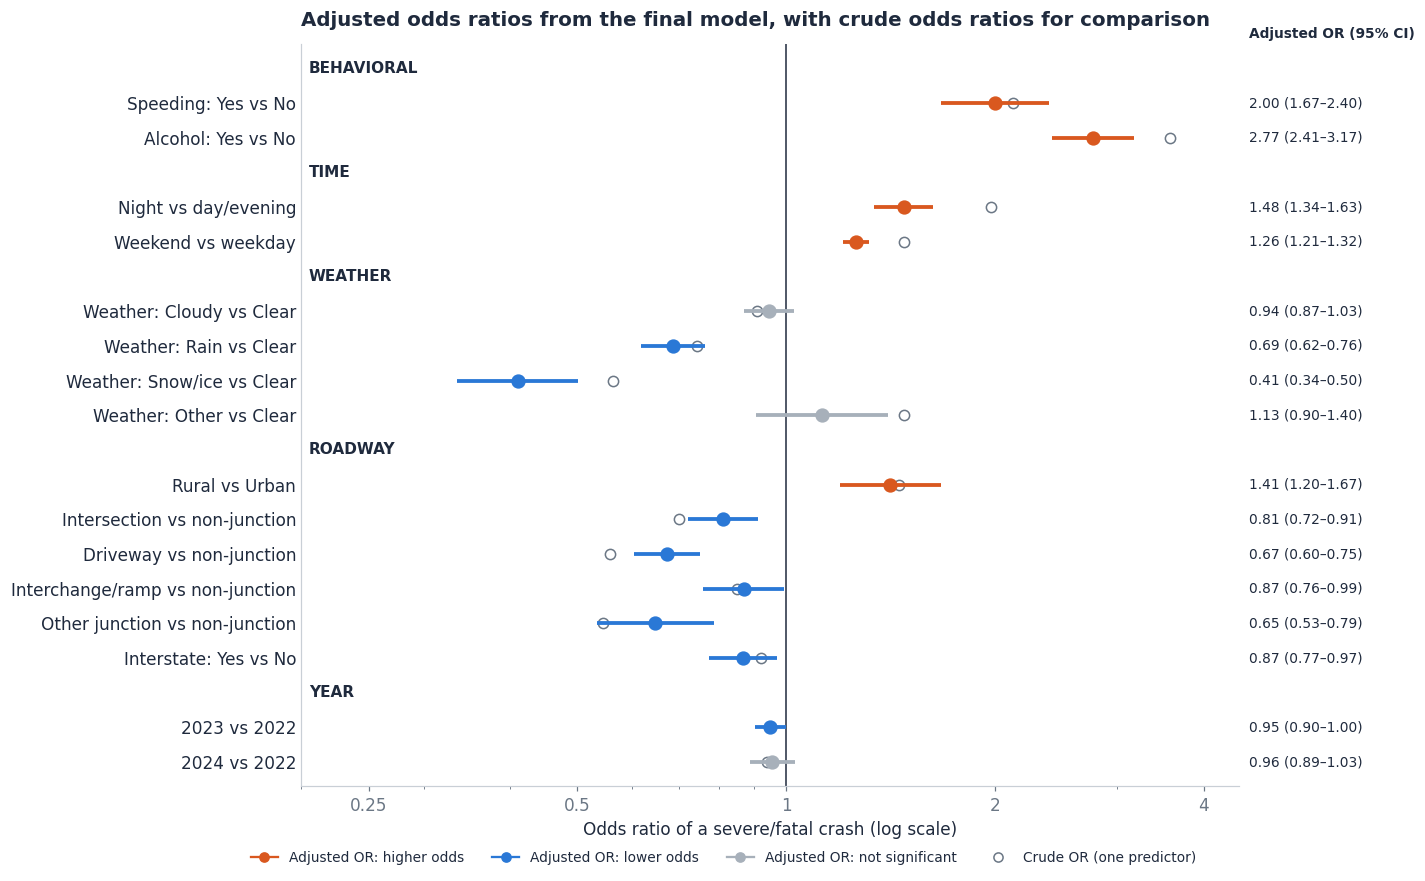

In [29]:
GROUPS = [
    ("Behavioral", ["C(speeding)[T.Yes]", "C(alcohol)[T.Yes]"]),
    ("Time", ["C(night)[T.Night]", "C(weekend)[T.Weekend]"]),
    ("Weather", ["C(weather)[T.Cloudy]", "C(weather)[T.Rain]", "C(weather)[T.Snow/ice]", "C(weather)[T.Other]"]),
    ("Roadway", ["C(urbanicity)[T.Rural]", "C(junction)[T.Intersection]", "C(junction)[T.Driveway]",
                 "C(junction)[T.Interchange/ramp]", "C(junction)[T.Other]", "C(interstate)[T.Yes]"]),
    ("Year", ["C(year)[T.2023]", "C(year)[T.2024]"]),
]
adj = or_table.set_index("term")
cru = crude.set_index("term")

rows = []
for gname, terms in GROUPS:
    rows.append(("header", gname, None))
    rows += [("term", pretty_names[t], t) for t in terms]

fig, ax = plt.subplots(figsize=(11, 0.36 * len(rows) + 1.2))
yy = np.arange(len(rows))[::-1]
for yi, (kind, label, t) in zip(yy, rows):
    if kind == "header":
        ax.text(0.205, yi, label.upper(), fontsize=10, fontweight="bold", color=INK, va="center")
        continue
    a, c = adj.loc[t], cru.loc[t]
    sig = a["p_value"] < 0.05
    col = (ACCENT if a["odds_ratio"] > 1 else BLUE) if sig else BASE
    ax.scatter(c["odds_ratio"], yi, marker="o", s=45, facecolor="white", edgecolor=MUTED, zorder=2)
    ax.hlines(yi, a["ci_low"], a["ci_high"], color=col, lw=2.5, zorder=3)
    ax.scatter(a["odds_ratio"], yi, color=col, s=70, zorder=4)
    ax.text(1.01, yi, f"{a['odds_ratio']:.2f} ({a['ci_low']:.2f}–{a['ci_high']:.2f})",
            transform=ax.get_yaxis_transform(), va="center", fontsize=9, color=INK)
ax.axvline(1, color=INK, lw=1)
ax.set_xscale("log")
ax.set_xlim(0.2, 4.5)
ax.set_xticks([0.25, 0.5, 1, 2, 4], ["0.25", "0.5", "1", "2", "4"])
ax.xaxis.set_minor_formatter(mtick.NullFormatter())
ax.set_yticks(yy, [lab if k == "term" else "" for k, lab, _ in rows])
ax.tick_params(axis="y", length=0)
ax.set_ylim(-0.7, len(rows) - 0.3)
ax.text(1.01, len(rows) - 0.2, "Adjusted OR (95% CI)", transform=ax.get_yaxis_transform(), fontsize=9,
        fontweight="bold", va="bottom")
ax.set_xlabel("Odds ratio of a severe/fatal crash (log scale)")
ax.legend(handles=[Line2D([], [], marker="o", color=ACCENT, ls="-", label="Adjusted OR: higher odds"),
                   Line2D([], [], marker="o", color=BLUE, ls="-", label="Adjusted OR: lower odds"),
                   Line2D([], [], marker="o", color=BASE, ls="-", label="Adjusted OR: not significant"),
                   Line2D([], [], marker="o", color=MUTED, mfc="white", ls="", label="Crude OR (one predictor)")],
          loc="upper center", bbox_to_anchor=(0.45, -0.07), ncol=4, fontsize=9)
ax.set_title("Adjusted odds ratios from the final model, with crude odds ratios for comparison")
save("13_forest_adjusted_vs_crude")

### 4.6 How to read the odds ratios

- **OR > 1:** the characteristic is associated with higher odds of a severe/fatal outcome.
- **OR < 1:** the characteristic is associated with lower odds.
- **OR ≈ 1 or CI crossing 1:** little adjusted association.
- "Change in odds" = (OR − 1) × 100%. For example, OR = 2.0 means 100% higher odds (double).

Odds ratios describe odds, not probabilities. Because severe/fatal crashes are rare (≈3%), odds and
probabilities are close here, so an OR of 2 roughly means "about twice as likely". Section 4.7 shows the
model's actual predicted probabilities.

**Interpretation of the final model (holding the other variables constant):**

- **Alcohol:** crashes involving alcohol have about **2.8 times the odds** of a severe/fatal outcome. This is the
  strongest association in the model.
- **Speeding:** speeding-related crashes have about **2.0 times the odds**.
- **Night:** night crashes (21:00–05:59) have about **1.5 times the odds** of day/evening crashes, even after
  accounting for alcohol and speeding.
- **Weekend:** weekend crashes have about **1.3 times the odds** (26% higher), smaller than the crude 1.48
  because part of the weekend pattern is a night pattern.
- **Rural:** rural crashes have about **1.4 times the odds** of urban crashes.
- **Weather:** rain (≈0.7) and snow/ice (≈0.4) are associated with lower odds than clear weather, which is
  consistent with drivers slowing down in bad conditions.
- **Junction:** crashes at intersections and driveways have lower odds than crashes away from junctions. The
  interchange/ramp difference is borderline and not significant under the full design check, so it is not
  interpreted.
- **Interstate:** interstate crashes have somewhat lower odds than non-interstate crashes.
- **Year:** the odds are about 4-5% lower in 2023 and 2024 than in 2022, but neither difference is significant
  under the full design check, so there is no clear trend over the three years.

These are **associations**: the model does not show that any of these characteristics causes a severe outcome.

### 4.7 Predicted probabilities for example crashes

To make the odds ratios concrete, the final model predicts the probability of a severe/fatal outcome for a few
example crashes. The baseline is a weekday, day/evening crash in clear weather, at an urban intersection,
not on an interstate, with no speeding or alcohol, in 2024. Each other example changes one or more
characteristics.

,Predicted severe/fatal probability (%)
Baseline crash,1.99
+ Rain,1.37
+ Night,2.90
"+ Rural, non-junction",3.41
+ Speeding,3.90
+ Alcohol,5.31
+ Speeding + alcohol,10.09
"Speeding + alcohol + night,\nrural, non-junction",22.43


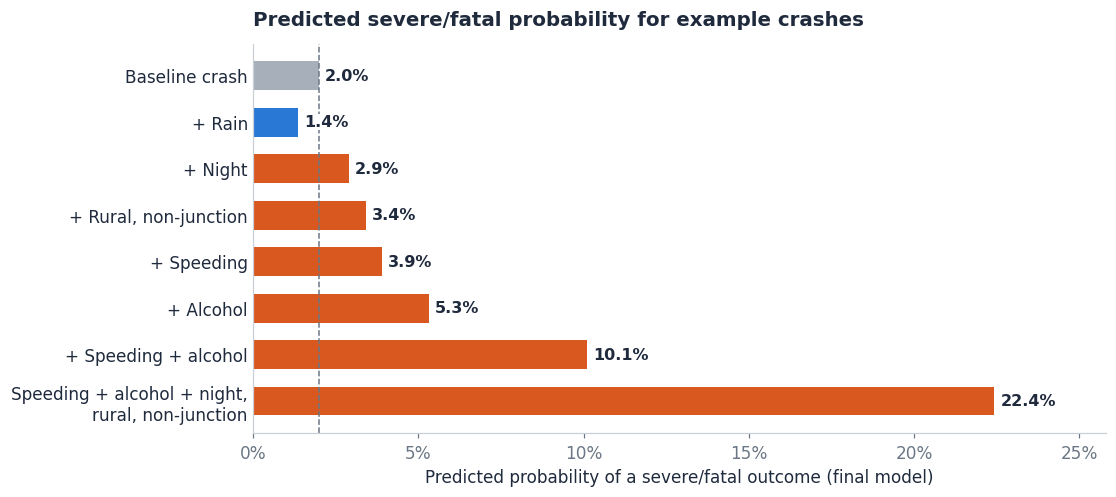

In [30]:
baseline = dict(speeding="No", alcohol="No", night="Day/evening", weekend="Weekday", weather="Clear",
                urbanicity="Urban", junction="Intersection", interstate="No", year=2024)
scenarios = {
    "Baseline crash": {},
    "+ Rain": {"weather": "Rain"},
    "+ Night": {"night": "Night"},
    "+ Rural, non-junction": {"urbanicity": "Rural", "junction": "Non-junction"},
    "+ Speeding": {"speeding": "Yes"},
    "+ Alcohol": {"alcohol": "Yes"},
    "+ Speeding + alcohol": {"speeding": "Yes", "alcohol": "Yes"},
    "Speeding + alcohol + night,\nrural, non-junction": {"speeding": "Yes", "alcohol": "Yes", "night": "Night",
                                                         "urbanicity": "Rural", "junction": "Non-junction"},
}
scen = pd.DataFrame([{**baseline, **changes} for changes in scenarios.values()], index=list(scenarios))
for col in PREDICTORS:
    scen[col] = pd.Categorical(scen[col], categories=model_df[col].cat.categories)
scen["predicted_pct"] = 100 * final.predict(scen)
display(scen[["predicted_pct"]].rename(columns={"predicted_pct": "Predicted severe/fatal probability (%)"}).round(2))

fig, ax = plt.subplots(figsize=(10, 4.6))
s = scen.iloc[::-1]
colors = [BASE if i == "Baseline crash" else BLUE if v < scen.loc["Baseline crash", "predicted_pct"] else ACCENT
          for i, v in zip(s.index, s["predicted_pct"])]
bars = ax.barh(s.index, s["predicted_pct"], color=colors, height=0.62)
for txt in ax.bar_label(bars, fmt="%.1f%%", padding=4, fontsize=10.5, fontweight="bold"):
    txt.set_bbox(dict(facecolor="white", edgecolor="none", pad=0.5))
ax.axvline(scen.loc["Baseline crash", "predicted_pct"], color=MUTED, ls="--", lw=1)
ax.set_xlim(0, s["predicted_pct"].max() * 1.15)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.tick_params(axis="y", length=0)
ax.set_xlabel("Predicted probability of a severe/fatal outcome (final model)")
ax.set_title("Predicted severe/fatal probability for example crashes")
save("14_predicted_probabilities")

The baseline crash has a predicted probability of about 2%. Rain lowers it to about 1.4%. Night, a rural
non-junction location, speeding and alcohol each raise it, to between 2.9% and 5.3%. Speeding plus alcohol
gives about 10%, and adding night and a rural non-junction location raises it to about 22%, roughly 11 times
the baseline. These are model predictions for illustration, not forecasts for individual crashes.

## 5. Main limitations

- Association, not causation: CRSS is observational, unmeasured factors (impact speed, seat-belt use,
   vehicle type, EMS response) may explain part of the associations.
- Police-reported crashes only: The results do not describe crashes that were never reported to police.
- Sampling design: Descriptive estimates use the CRSS sampling weights. The regression uses normalized
   weights and PSU-clustered standard errors, which ignore the sampling strata, statsmodels flags this setup as
   not fully supported. A design-based check with strata and PSUs (Section 4.5) confirms all main conclusions,
   but p-values are approximate and borderline results (interchange/ramp, 2023 vs 2022) are not interpreted.
- Measurement: Alcohol (NHTSA-imputed when unknown), speeding and injury severity depend on police reporting
   and judgment at the scene.
- Crash-level aggregation: Speeding is derived from vehicle records and aggregated to the crash.
- Excluded crashes: About 4% of crashes with unknown speeding or interstate status are not in the model.
- Three-year period: The analysis describes 2022-2024 and should not automatically be generalized to other periods.

## 6. Summary of findings

- About 3.2% of police-reported crashes in 2022-2024 were severe or fatal (≈194,000 per year).
- Descriptively, alcohol, speeding, night, darkness and rural settings are linked to clearly higher
  severe/fatal shares, while rain and snow/ice crashes are less often severe.
- After adjustment, the strongest associations are alcohol (OR ≈ 2.77) and speeding (OR ≈ 2.0),
  followed by night (≈1.5), rural location (≈1.4) and weekend (≈1.26). Adverse weather remains associated with lower odds.
- Combined, these characteristics raise the predicted probability of a severe/fatal outcome from about
  2% for a typical daytime urban intersection crash to about 22% for a rural, nighttime crash with speeding and alcohol.
- The patterns are stable across 2022-2024.